In [ ]:
!pip install --upgrade datasets transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 13.4 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.9.0
    Uninstalling transformers-5.9.0:
      Successfully uninstalled transformers-5.9.0


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving skincare-labeled.xlsx to skincare-labeled.xlsx


In [ ]:
import pandas as pd

data = pd.read_excel("skincare-labeled.xlsx")

# Data sudah diberi label sentimen secara manual (0=Positive, 1=Neutral, 2=Negative)
data.head()

,text,clean_text,tokenized_text,normalized_text,label
0,Rejuvenate & transform your skin with these e...,rejuvenate transform your skin with these effe...,"['rejuvenate', 'transform', 'your', 'skin', 'w...",rejuvenate transform your skin with these effe...,0
1,"Keknya skinker/? Ini sama kayak disini, dia ma...","keknya skinker ? ini sama kayak disini, dia ma...","['keknya', 'skinker', '?', 'ini', 'sama', 'kay...","kayaknya skincare ? ini sama kayak disini , di...",2
2,Tuhkan emang skincare ini bagus banget buat ny...,tuhkan emang skincare ini bagus banget buat ny...,"['tuhkan', 'emang', 'skincare', 'ini', 'bagus'...",tuhkan memang skincare ini bagus banget buat n...,0
3,Btw skintype aku oily acne prone. Dari dulu ka...,btw skintype aku oily acne prone. dari dulu ka...,"['btw', 'skintype', 'aku', 'oily', 'acne', 'pr...",btw skin type aku oily acne prone . dari dulu ...,2
4,"@ohmybeautybank BENER SEKALIIIII, sebagus ituu...","bener sekaliiiii, sebagus ituuu, pake yang ijo...","['bener', 'sekaliiiii', ',', 'sebagus', 'ituuu...","benar sekali , sebagus itu , pakai yang ijo je...",0


In [ ]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_ib = 1

ib_results = []
all_y_true_ib = []
all_y_pred_ib = []

all_train_loss = []
all_eval_loss = []
all_eval_acc = []

label_map = {0:"Positive", 1:"Neutral", 2:"Negative"}

In [ ]:
import numpy as np
import torch
import random
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
# Load tokenizer dari pre-trained model IndoBERT
tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p2", use_fast=True)
tokenizer.add_tokens([ 'NaN' ])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1

In [ ]:
# Fungsi untuk proses tokenisasi teks
def tokenize_function(examples):
  # Memotong teks jika terlalu panjang (truncation) dan menambahkan padding agar seragam (maksimal 128 token)
  return tokenizer(examples["normalized_text"], padding='max_length', truncation=True, max_length=128)

In [ ]:
# Fungsi metrik evaluasi
def compute_metrics(eval_pred):
  logits, labels = eval_pred
  predictions = np.argmax(logits, axis=-1)

  acc = accuracy_score(labels, predictions)
  precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='macro', zero_division=0)

  return {
      "accuracy_ib": acc,
      "precision_macro_ib": precision,
      "recall_macro_ib": recall,
      "f1_macro_ib": f1
  }

In [ ]:
class CustomTrainer(Trainer):
  def __init__(self,class_weights=None,*args,**kwargs):
    super().__init__(*args, **kwargs)
    self.class_weights = class_weights

  def compute_loss(self,model,inputs,return_outputs=False,**kwargs):
    labels = inputs.pop("labels")
    outputs = model(**inputs)
    logits = outputs.logits
    loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
    loss = loss_fct(logits.view(-1,model.config.num_labels),labels.view(-1))

    return (loss, outputs) if return_outputs else loss


===== IndoBERT FOLD 1 =====


Map:   0%|          | 0/2269 [00:00<?, ? examples/s]

Map:   0%|          | 0/568 [00:00<?, ? examples/s]

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

...

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy Ib,Precision Macro Ib,Recall Macro Ib,F1 Macro Ib
1,0.767025,0.435716,0.878521,0.824564,0.833945,0.827006
2,0.363916,0.352400,0.904930,0.849717,0.876551,0.862407
3,0.190682,0.330329,0.910211,0.851893,0.905033,0.875620


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Distribusi Sentimen (IndoBERT) Fold 1
          Jumlah  Persentase (%)
Positive     125           22.01
Neutral      362           63.73
Negative      81           14.26


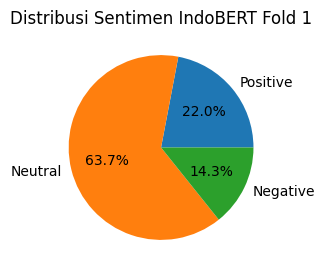


Classification Report IndoBERT Fold 1
              precision    recall  f1-score   support

    Positive       0.80      0.88      0.84       113
     Neutral       0.98      0.92      0.95       386
    Negative       0.78      0.91      0.84        69

    accuracy                           0.91       568
   macro avg       0.85      0.91      0.88       568
weighted avg       0.92      0.91      0.91       568


===== IndoBERT FOLD 2 =====


Map:   0%|          | 0/2269 [00:00<?, ? examples/s]

Map:   0%|          | 0/568 [00:00<?, ? examples/s]

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy Ib,Precision Macro Ib,Recall Macro Ib,F1 Macro Ib
1,0.767503,0.377968,0.846831,0.766583,0.860572,0.801651
2,0.322868,0.315998,0.897887,0.837852,0.901074,0.865110
3,0.178264,0.372556,0.894366,0.836542,0.867403,0.850987


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Distribusi Sentimen (IndoBERT) Fold 2
          Jumlah  Persentase (%)
Positive     122           21.48
Neutral      371           65.32
Negative      75           13.20


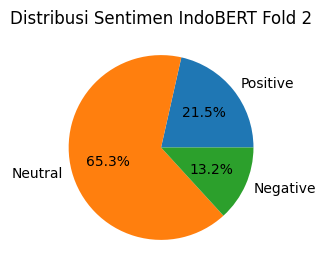


Classification Report IndoBERT Fold 2
              precision    recall  f1-score   support

    Positive       0.81      0.88      0.84       113
     Neutral       0.95      0.91      0.93       386
    Negative       0.75      0.81      0.78        69

    accuracy                           0.89       568
   macro avg       0.84      0.87      0.85       568
weighted avg       0.90      0.89      0.90       568


===== IndoBERT FOLD 3 =====


Map:   0%|          | 0/2270 [00:00<?, ? examples/s]

Map:   0%|          | 0/567 [00:00<?, ? examples/s]

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy Ib,Precision Macro Ib,Recall Macro Ib,F1 Macro Ib
1,0.736166,0.443097,0.827160,0.747067,0.835497,0.772541
2,0.316165,0.396381,0.873016,0.802021,0.872597,0.831379
3,0.181012,0.428546,0.873016,0.798224,0.874275,0.827446


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Distribusi Sentimen (IndoBERT) Fold 3
          Jumlah  Persentase (%)
Positive     120           21.16
Neutral      349           61.55
Negative      98           17.28


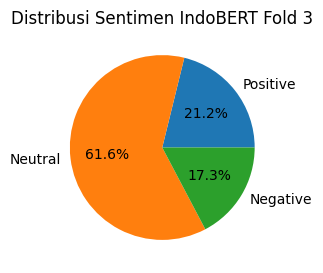


Classification Report IndoBERT Fold 3
              precision    recall  f1-score   support

    Positive       0.78      0.83      0.81       113
     Neutral       0.97      0.88      0.92       385
    Negative       0.64      0.91      0.75        69

    accuracy                           0.87       567
   macro avg       0.80      0.87      0.83       567
weighted avg       0.89      0.87      0.88       567


===== IndoBERT FOLD 4 =====


Map:   0%|          | 0/2270 [00:00<?, ? examples/s]

Map:   0%|          | 0/567 [00:00<?, ? examples/s]

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy Ib,Precision Macro Ib,Recall Macro Ib,F1 Macro Ib
1,0.727464,0.442832,0.858907,0.790808,0.863789,0.820901
2,0.328391,0.487384,0.876543,0.812346,0.848453,0.828927
3,0.182963,0.493139,0.885362,0.826832,0.873014,0.847083


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Distribusi Sentimen (IndoBERT) Fold 4
          Jumlah  Persentase (%)
Positive     134           23.63
Neutral      358           63.14
Negative      75           13.23


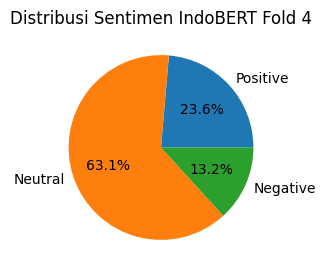


Classification Report IndoBERT Fold 4
              precision    recall  f1-score   support

    Positive       0.75      0.88      0.81       113
     Neutral       0.96      0.89      0.93       385
    Negative       0.77      0.84      0.81        69

    accuracy                           0.89       567
   macro avg       0.83      0.87      0.85       567
weighted avg       0.90      0.89      0.89       567


===== IndoBERT FOLD 5 =====


Map:   0%|          | 0/2270 [00:00<?, ? examples/s]

Map:   0%|          | 0/567 [00:00<?, ? examples/s]

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy Ib,Precision Macro Ib,Recall Macro Ib,F1 Macro Ib
1,0.748103,0.414220,0.791887,0.713602,0.839022,0.745327
2,0.311551,0.317576,0.888889,0.811844,0.884557,0.841610
3,0.163489,0.320011,0.901235,0.835285,0.888939,0.858920


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Distribusi Sentimen (IndoBERT) Fold 5
          Jumlah  Persentase (%)
Positive     131           23.10
Neutral      357           62.96
Negative      79           13.93


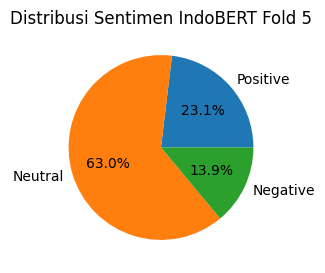


Classification Report IndoBERT Fold 5
              precision    recall  f1-score   support

    Positive       0.78      0.90      0.84       113
     Neutral       0.98      0.91      0.94       385
    Negative       0.75      0.86      0.80        69

    accuracy                           0.90       567
   macro avg       0.84      0.89      0.86       567
weighted avg       0.91      0.90      0.90       567



In [ ]:
for train_idx, eval_idx in skf.split(data["normalized_text"],data["label"]):
  print(f"\n===== IndoBERT FOLD {fold_ib} =====")

  # Bagi data menjadi data latih (train) dan data evaluasi (eval)
  train_data = data.iloc[train_idx]
  eval_data = data.iloc[eval_idx]

  # Ambil label dari data latih untuk menghitung bobot kelas
  labels = train_data["label"]

  # Hitung bobot kelas untuk menangani masalah imbalanced data
  class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)
  class_weights = torch.tensor(class_weights, dtype=torch.float)

  # Mengubah data dari format Pandas DataFrame ke format Dataset dari Hugging Face
  train_dataset = Dataset.from_pandas(train_data[["normalized_text","label"]])
  eval_dataset = Dataset.from_pandas(eval_data[["normalized_text","label"]])

  # Menerapkan fungsi tokenisasi
  train_dataset = train_dataset.map(tokenize_function,batched=True)
  train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

  eval_dataset = eval_dataset.map(tokenize_function,batched=True)
  eval_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

  # Load model IndoBERT
  model = AutoModelForSequenceClassification.from_pretrained("indobenchmark/indobert-base-p2", num_labels=3)

  # Konfigurasi training
  training_args = TrainingArguments(
    output_dir=f"./result_fold_{fold_ib}",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    fp16=True,
    eval_strategy="epoch",
    logging_strategy="epoch",
    seed=42,
    data_seed=42
  )

  # Inisialisasi trainer
  trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
    class_weights=class_weights
  )

  # Training
  trainer.train()

  log_history = trainer.state.log_history
  train_loss = [x['loss'] for x in log_history if 'loss' in x]
  eval_loss = [x['eval_loss'] for x in log_history if 'eval_loss' in x]
  eval_acc = [x['eval_accuracy_ib'] for x in log_history if 'eval_accuracy_ib' in x]
  epochs_train = [x['epoch'] for x in log_history if 'loss' in x]
  epochs_eval = [x['epoch'] for x in log_history if 'eval_loss' in x]

  all_train_loss.append(train_loss)
  all_eval_loss.append(eval_loss)
  all_eval_acc.append(eval_acc)

  # Prediksi sekaligus  evaluasi
  pred = trainer.predict(eval_dataset)
  y_pred = np.argmax(pred.predictions,axis=1)
  y_true = pred.label_ids

  all_y_true_ib.extend(y_true)
  all_y_pred_ib.extend(y_pred)

  # Ekstraksi hasil metrik dari proses prediksi
  result = pred.metrics
  result["fold"] = fold_ib
  ib_results.append(result)

  # Hitung distribusi sentimen
  sentiment_dist = pd.Series(y_pred).value_counts().sort_index()
  sentiment_dist.index = sentiment_dist.index.map(label_map)
  sentiment_percent = sentiment_dist / sentiment_dist.sum() * 100

  sentiment_summary = pd.DataFrame({
    "Jumlah": sentiment_dist,
    "Persentase (%)": sentiment_percent.round(2)
  })

  print(f"\nDistribusi Sentimen (IndoBERT) Fold {fold_ib}")
  print(sentiment_summary)

  # Pie Chart Distribusi Sentimen
  sentiment_summary["Jumlah"].plot(kind="pie",autopct="%1.1f%%",figsize=(3,3), title=f"Distribusi Sentimen IndoBERT Fold {fold_ib}")
  plt.ylabel("")
  plt.show()

  # Classification Report
  print(f"\nClassification Report IndoBERT Fold {fold_ib}")
  print(classification_report(y_true, y_pred, target_names=["Positive", "Neutral", "Negative"]))

  # Lanjut ke fold berikutnya
  fold_ib += 1

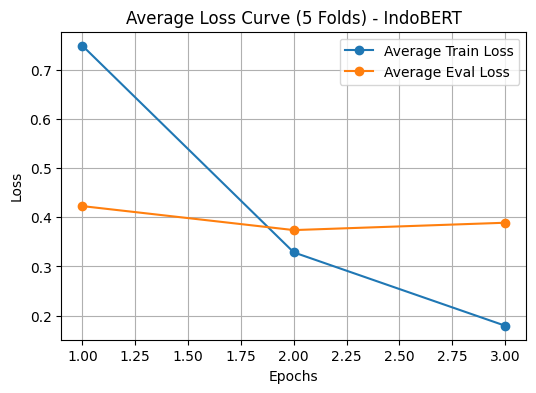

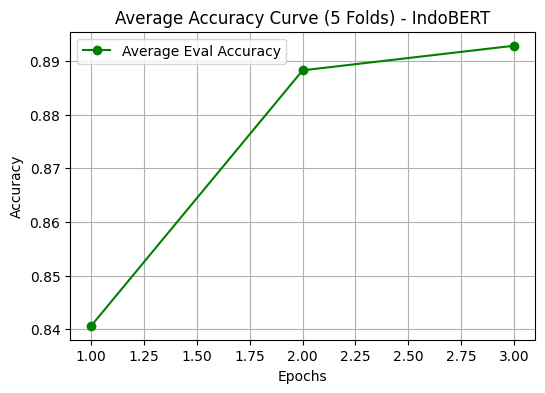

In [ ]:
# Hitung rata-rata tiap epoch
avg_train_loss = np.mean(all_train_loss, axis=0)
avg_eval_loss = np.mean(all_eval_loss, axis=0)
avg_eval_acc = np.mean(all_eval_acc, axis=0)

epochs = range(1, len(avg_train_loss)+1)

# Average Loss Curve
plt.figure(figsize=(6,4))

plt.plot(epochs, avg_train_loss, marker='o', label='Average Train Loss')
plt.plot(epochs, avg_eval_loss, marker='o', label='Average Eval Loss')

plt.title('Average Loss Curve (5 Folds) - IndoBERT')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

# Average Accuracy Curve
plt.figure(figsize=(6,4))

plt.plot(epochs, avg_eval_acc, marker='o', color='green', label='Average Eval Accuracy')

plt.title('Average Accuracy Curve (5 Folds) - IndoBERT')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Mengambil nilai F1-Score Macro dari seluruh fold
f1_indobert = [result["test_f1_macro_ib"] for result in ib_results]

print("F1-Score Macro IndoBERT per Fold:", f1_indobert)

F1-Score Macro IndoBERT per Fold: [0.8756200662083015, 0.8509865890511777, 0.8274462990614296, 0.8470826428784918, 0.8589196991609612]


In [ ]:
avg_ib_accuracy = np.mean(result["test_accuracy_ib"])
avg_ib_recall = np.mean(result["test_recall_macro_ib"])
avg_ib_precision = np.mean(result["test_precision_macro_ib"])
avg_ib_f1score = np.mean(result["test_f1_macro_ib"])

print(f"Average IndoBERT Accuracy: {avg_ib_accuracy:.4f}")
print(f"Average IndoBERT Recall: {avg_ib_recall:.4f}")
print(f"Average IndoBERT Precision: {avg_ib_precision:.4f}")
print(f"Average IndoBERT F1-Score: {avg_ib_f1score:.4f}")

Average IndoBERT Accuracy: 0.9012
Average IndoBERT Recall: 0.8889
Average IndoBERT Precision: 0.8353
Average IndoBERT F1-Score: 0.8589


Classification Report Keseluruhan (Semua Fold)
              precision    recall  f1-score   support

    Positive       0.78      0.88      0.83       565
     Neutral       0.97      0.90      0.93      1927
    Negative       0.73      0.87      0.79       345

    accuracy                           0.89      2837
   macro avg       0.83      0.88      0.85      2837
weighted avg       0.90      0.89      0.90      2837



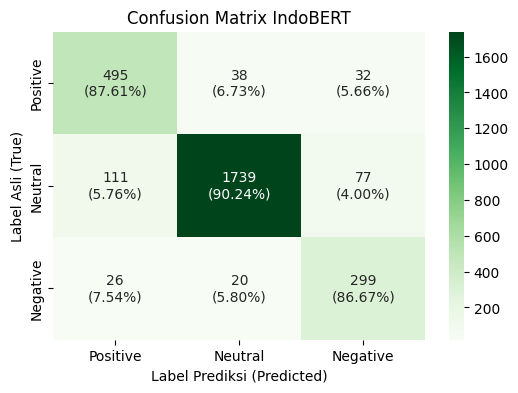

In [ ]:
print("Classification Report Keseluruhan (Semua Fold)")

# class-wise metrics
print(classification_report(all_y_true_ib, all_y_pred_ib, target_names=["Positive", "Neutral", "Negative"]))

# Confusion Matrix
cm = confusion_matrix(all_y_true_ib, all_y_pred_ib)

# Persentase per baris (berdasarkan label asli)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Gabungkan nilai absolut + persen
labels = np.array([
    [f"{cm[i,j]}\n({cm_percent[i,j]:.2f}%)" for j in range(cm.shape[1])]
    for i in range(cm.shape[0])
])

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Greens",
    xticklabels=["Positive", "Neutral", "Negative"],
    yticklabels=["Positive", "Neutral", "Negative"]
)

plt.title("Confusion Matrix IndoBERT")
plt.ylabel("Label Asli (True)")
plt.xlabel("Label Prediksi (Predicted)")

plt.show()